In [1]:
ls

all_data_decomposed_100ms_1core.csv      all_data_decomposed_200ms_hybrid.csv
all_data_decomposed_100ms_apiserver.csv  all_data_decomposed_50ms_1core.csv
all_data_decomposed_100ms.csv            all_data_decomposed_50ms_apiserver.csv
all_data_decomposed_100ms_hybrid.csv     all_data_decomposed_50ms.csv
all_data_decomposed_10ms_1core.csv       all_data_decomposed_50ms_hybrid.csv
all_data_decomposed_10ms_apiserver.csv   fig_ecdf_osdi.pdf
all_data_decomposed_10ms.csv             fig_ecdf_osdi.png
all_data_decomposed_10ms_hybrid.csv      fig_tail_cold_abs.pdf
all_data_decomposed_1s_1core.csv         fig_tail_cold_abs.png
all_data_decomposed_1s_apiserver.csv     fig_tail_warm_abs.pdf
all_data_decomposed_1s.csv               fig_tail_warm_abs.png
all_data_decomposed_1s_hybrid.csv        resp_ecdf_overlay.pdf
all_data_decomposed_200ms_1core.csv      resp_ecdf_overlay.png
all_data_decomposed_200ms_apiserver.csv  Untitled4.ipynb
all_data_decomposed_200ms.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 20000 samples, median=494.9ms, p99=28751.8ms
  [OK]   Hybrid / 10ms — 20000 samples, median=370.2ms, p99=22150.4ms
  [OK]   Local 1core / 10ms — 20000 samples, median=456.3ms, p99=31979.5ms
  [OK]   Local Apiserver / 10ms — 20000 samples, median=556.0ms, p99=22942.8ms
  [OK]   Local / 50ms — 20010 samples, median=699.6ms, p99=20165.7ms
  [OK]   Hybrid / 50ms — 20010 samples, median=129.6ms, p99=3478.8ms
  [OK]   Local 1core / 50ms — 20010 samples, median=143.3ms, p99=6645.8ms
  [OK]   Local Apiserver / 50ms — 20010 samples, median=158.5ms, p99=7826.9ms
  [OK]   Local / 100ms — 20010 samples, median=133.9ms, p99=2448.0ms
  [OK]   Hybrid / 100ms — 20010 samples, median=129.6ms, p99=1169.5ms
  [OK]   Local 1core / 100ms — 20010 samples, median=140.1ms, p99=2181.9ms
  [OK]   Local Apiserver / 100ms — 20010 samples, median=145.4ms, p99=6503.6ms
  [OK]   Local / 200ms — 20010 samples, median=125.8ms, p99=673.4

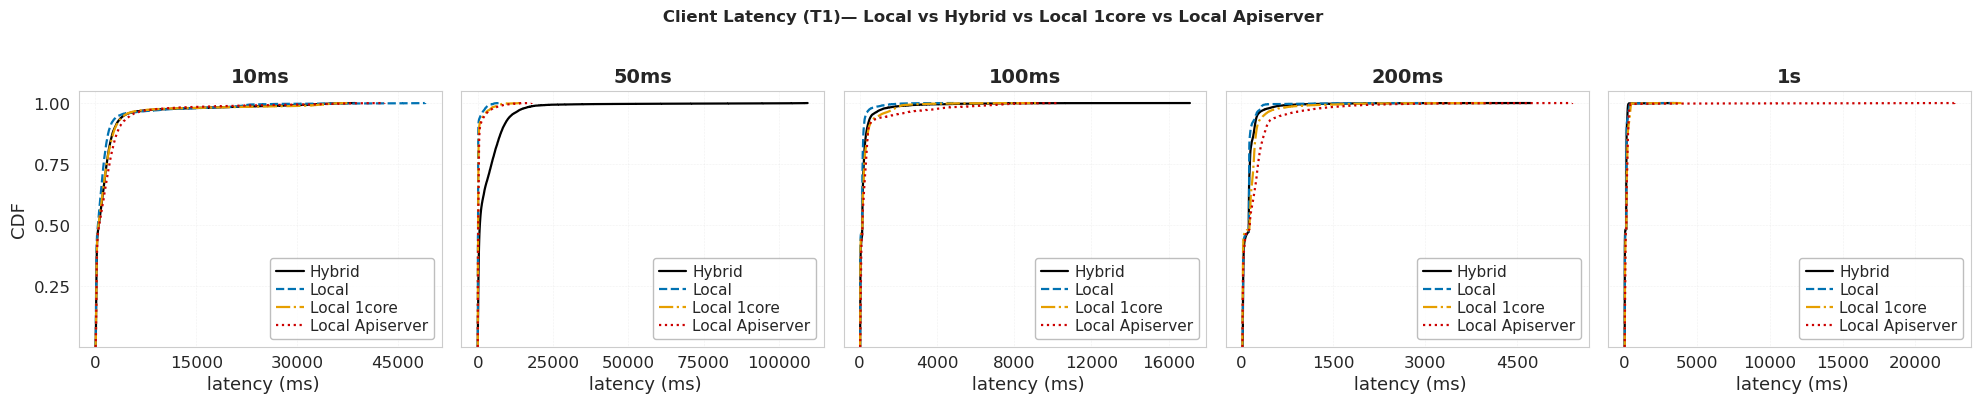

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#000000", "#0072B2", "#E69F00", "#CC0000"]
LINESTYLES = ["-",       "--",      "-.",      ":"]
LABELS     = ["Hybrid",  "Local", "Local 1core","Local Apiserver"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local":       {d: f"all_data_decomposed_{d}.csv"        for d in DELAYS},
    "Local 1core": {d: f"all_data_decomposed_{d}_1core.csv"  for d in DELAYS},
    "Hybrid":      {d: f"all_data_decomposed_{d}_hybrid.csv" for d in DELAYS},
    "Local Apiserver": {d: f"all_data_decomposed_{d}_apiserver.csv" for d in DELAYS},
}

MODES = ["Local", "Hybrid", "Local 1core", "Local Apiserver"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["latency_ms"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel(" latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    " Client Latency (T1)— Local vs Hybrid vs Local 1core vs Local Apiserver",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "resp_ecdf_overlay.pdf"
out_png = "resp_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

Available delays: ['10ms', '50ms', '100ms', '200ms', '1s']
✓ fig_ecdf_osdi.pdf / .png


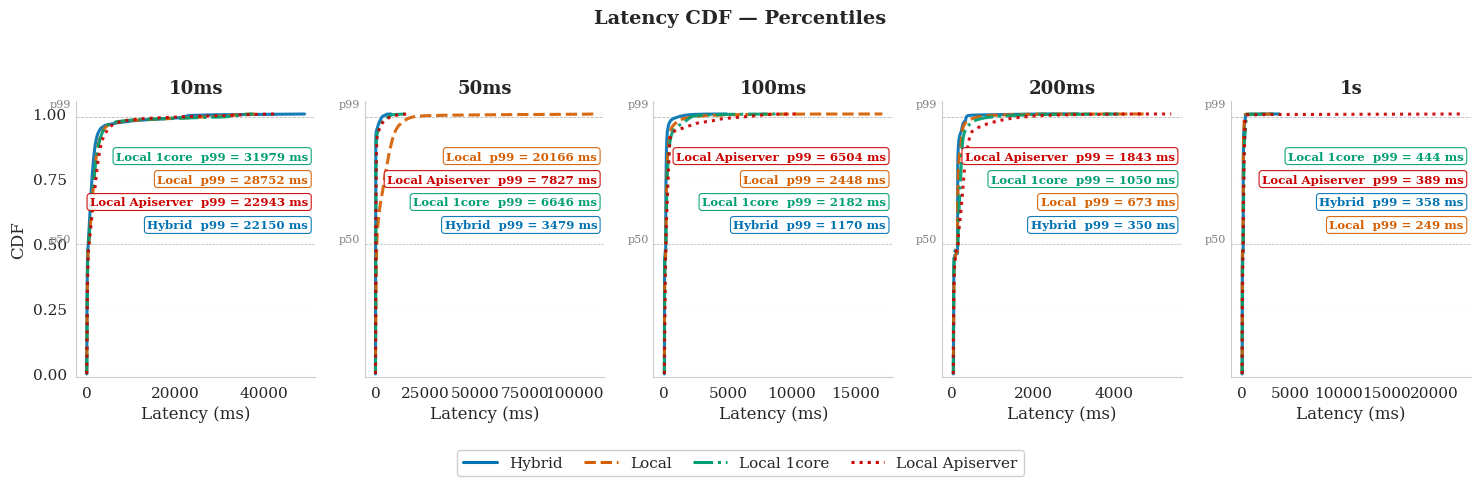

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.lines import Line2D

# ── Typography (OSDI / ACM SOSP style) ───────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         13,
    "axes.titlesize":    14,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "lines.linewidth":   2.2,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Palette (Wong 2011, colorblind-safe, readable in B&W) ────────────────────
STYLES = {
    "Hybrid":      ("#0072B2", "-"),
    "Local":       ("#D55E00", "--"),
    "Local 1core": ("#009E73", "-."),
    "Local Apiserver": ("#CC0000", ":")
}
MODES = list(STYLES.keys())

# ── Config ────────────────────────────────────────────────────────────────────
DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s"]
DATA_DIR = "."
FILES = {
    "Local":       {d: f"all_data_decomposed_{d}.csv"        for d in DELAYS},
    "Local 1core": {d: f"all_data_decomposed_{d}_1core.csv"  for d in DELAYS},
    "Hybrid":      {d: f"all_data_decomposed_{d}_hybrid.csv" for d in DELAYS},
   "Local Apiserver": {d: f"all_data_decomposed_{d}_apiserver.csv" for d in DELAYS}
}


# ── Helpers ───────────────────────────────────────────────────────────────────
def load_series(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path):
        return None
    s = pd.read_csv(path)["latency_ms"].dropna()
    return s if len(s) > 0 else None


def ecdf(data):
    xs = np.sort(data)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys


available = [d for d in DELAYS if any(load_series(m, d) is not None for m in MODES)]
print(f"Available delays: {available}")

# ── Layout ────────────────────────────────────────────────────────────────────
n     = len(available)
COL_W = 3.0
fig, axes = plt.subplots(1, n, figsize=(COL_W * n, 4.2), sharey=True)
if n == 1:
    axes = [axes]

for ci, delay in enumerate(available):
    ax = axes[ci]

    # p99 / p50 horizontal guide lines
    ax.axhline(0.99, color="0.72", linewidth=0.6, linestyle="--", zorder=1)
    ax.text(-0.02, 0.99, "p99", transform=ax.transAxes,
            ha="right", va="center", fontsize=8, color="0.50")
    ax.axhline(0.50, color="0.72", linewidth=0.5, linestyle="--", zorder=1)
    ax.text(-0.02, 0.50, "p50", transform=ax.transAxes,
            ha="right", va="center", fontsize=8, color="0.50")

    # Collect p99 per arch for stacked annotations
    p99_entries = []

    for arch in MODES:
        data = load_series(arch, delay)
        if data is None:
            continue
        color, ls = STYLES[arch]
        xs, ys = ecdf(data.values)
        ax.plot(xs, ys, color=color, linestyle=ls, linewidth=2.2,
                alpha=0.92, zorder=3)
        p99_val = float(np.percentile(data, 99))
        p99_entries.append((p99_val, color, arch))

    # ── p99 annotations — stacked, no arrows, no lines ───────────────────
    p99_entries.sort(key=lambda x: x[0])
    n_arches  = len(p99_entries)
    y_offsets = np.linspace(0.55, 0.80, n_arches)   # axes fraction

    for idx, (p99_val, color, arch) in enumerate(p99_entries):
        label = f"{arch}  p99 = {p99_val:.0f} ms"
        ax.text(
            0.97, y_offsets[idx],
            label,
            transform=ax.transAxes,
            ha="right", va="center",
            fontsize=8.5,
            color=color,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor=color,
                linewidth=0.8,
                alpha=0.92,
            ),
            zorder=6,
        )

    ax.set_title(delay, fontweight="bold", fontsize=13, pad=6)
    ax.set_xlabel("Latency (ms)", fontsize=12, labelpad=4)
    ax.set_ylim(-0.01, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.tick_params(axis="both", direction="out", length=3, width=0.6)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.35, color="0.80", zorder=0)
    ax.grid(False, axis="x")

    if ci == 0:
        ax.set_ylabel("CDF", fontsize=12)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color=STYLES[a][0], linestyle=STYLES[a][1],
           linewidth=2.2, label=a)
    for a in MODES
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(MODES),
    bbox_to_anchor=(0.5, -0.10),
    fontsize=11,
    framealpha=0.95,
    edgecolor="0.80",
    handlelength=2.2,
    columnspacing=1.4,
)

fig.suptitle("Latency CDF — Percentiles",
             fontsize=14, fontweight="bold", y=1.03)

plt.tight_layout(rect=[0, 0.0, 1, 1.0])

fig.savefig("fig_ecdf_osdi.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_ecdf_osdi.png", dpi=300, bbox_inches="tight")
print("✓ fig_ecdf_osdi.pdf / .png")

Delays (cold): ['10ms', '50ms', '100ms', '200ms', '1s']
✓ fig_tail_cold_abs.pdf
✓ fig_tail_cold_abs.png


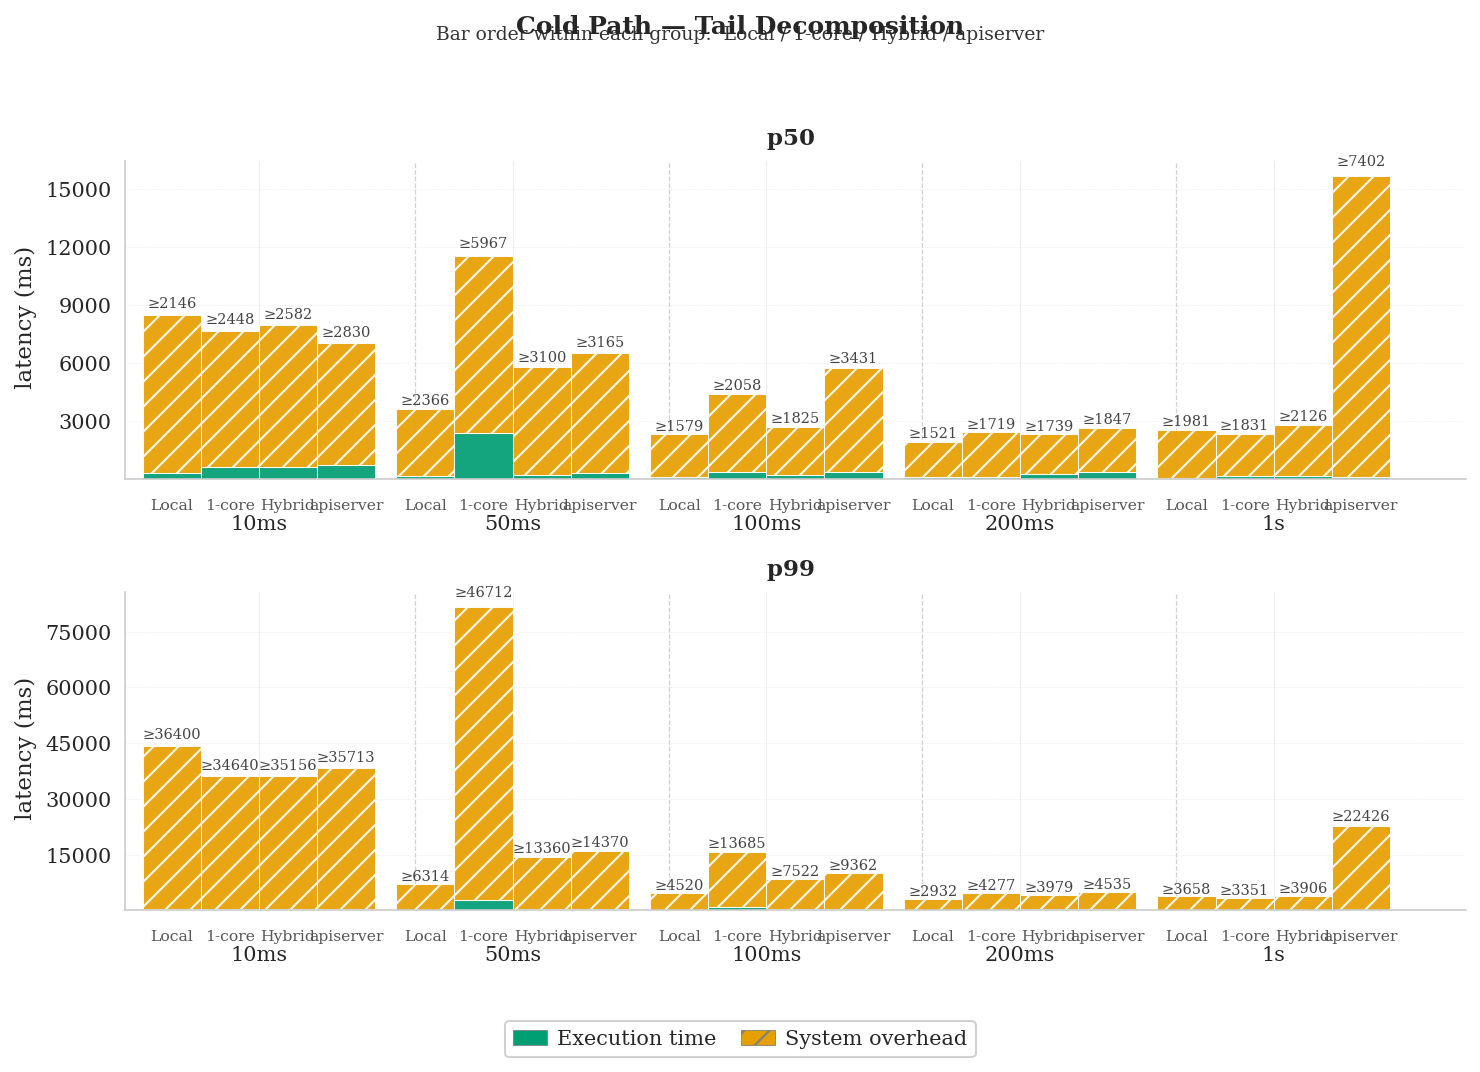

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Typography & style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "pdf.fonttype":       42,   # embeds fonts properly for ACM/IEEE
    "ps.fonttype":        42,
    "figure.dpi":         150,
})

# ── Data configuration ────────────────────────────────────────────────────────
DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s"]
ARCHS    = ["Hybrid", "Local", "Local 1core","Local Apiserver"]
DATA_DIR = "."
FILES = {
    "Local":       {d: f"all_data_decomposed_{d}.csv"         for d in DELAYS},
    "Local 1core": {d: f"all_data_decomposed_{d}_1core.csv"   for d in DELAYS},
    "Hybrid":      {d: f"all_data_decomposed_{d}_hybrid.csv"  for d in DELAYS},
   "Local Apiserver": {d: f"all_data_decomposed_{d}_apiserver.csv"  for d in DELAYS}
}

# Stack: only the two decomposed columns (output transfer is implicit remainder)
STACK_COLS    = ["execution_time_ms", "system_overhead_ms"]
STACK_LABELS  = ["Execution time", "System overhead"]
# Colorblind-safe, print-friendly palette (Wong 2011)
STACK_COLORS  = ["#009E73", "#E69F00"]
STACK_HATCHES = ["", "//"]

REQ_TYPE = "cold"

# ── Helpers ───────────────────────────────────────────────────────────────────
def load(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df = df[(df["status"] == 200) & (df["type"] == REQ_TYPE)].copy()
    for col in STACK_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df if len(df) > 0 else None


def tail_decomp(df, pctile):
    thresh = np.percentile(df["latency_ms"].dropna(), pctile)
    tail   = df[df["latency_ms"] >= thresh]
    result = {col: (tail[col].mean() if len(tail) > 0 else 0) for col in STACK_COLS}
    result["n_tail"] = len(tail)
    result["thresh"] = thresh
    return result


available = [d for d in DELAYS if any(load(a, d) is not None for a in ARCHS)]
print(f"Delays ({REQ_TYPE}): {available}")

# ── Layout ────────────────────────────────────────────────────────────────────
# One row per percentile; columns = network delays
# Column width generous so group labels breathe
PCTILES    = [50, 99]
ROW_TITLES = ["p50 ",
              "p99 "]
N_ARCH = len(ARCHS)
n      = len(available)

ARCH_LABELS = ["Local", "1-core", "Hybrid", "Apiserver"]  # concise x-tick labels

# Group layout: for each delay, 3 bars (one per arch) + small gap between groups
bar_w    = 0.22
gap      = 0.08                              # gap between groups
group_w  = N_ARCH * bar_w + gap
x_groups = np.arange(n) * group_w           # left edge of each group
x_arches = [x_groups + i * bar_w for i in range(N_ARCH)]

fig, axes = plt.subplots(
    len(PCTILES), 1,
    figsize=(max(6, 2.0 * n), 6.5),
    sharex=False,
)
if len(PCTILES) == 1:
    axes = [axes]

for row, (pctile, row_title) in enumerate(zip(PCTILES, ROW_TITLES)):
    ax = axes[row]
    thresh_texts = []

    for ai, arch in enumerate(ARCHS):
        for ci, delay in enumerate(available):
            df = load(arch, delay)
            if df is None:
                thresh_texts.append(None)
                continue

            decomp = tail_decomp(df, pctile)
            bottom = 0
            xpos   = x_arches[ai][ci]

            for col, color, hatch in zip(STACK_COLS, STACK_COLORS, STACK_HATCHES):
                val = decomp.get(col, 0)
                ax.bar(
                    xpos, val,
                    bottom=bottom,
                    width=bar_w,
                    color=color,
                    hatch=hatch,
                    edgecolor="white",
                    linewidth=0.5,
                    alpha=0.92,
                    label=None,
                )
                bottom += val

            # Threshold annotation above bar
            ax.text(
                xpos, bottom + max(bottom * 0.025, 2),
                f"≥{decomp['thresh']:.0f}",
                ha="center", va="bottom",
                fontsize=7, color="#444444",
                rotation=0,
            )

    # ── X-axis: group ticks = delays, minor visual separators ───────────────
    group_centers = x_groups + (N_ARCH * bar_w) / 2 - bar_w / 2
    ax.set_xticks(group_centers)
    ax.set_xticklabels(available, fontsize=10)
    ax.set_xlabel("", fontsize=11, labelpad=6)

    # Arch labels below each bar — secondary level
    for ai, label in enumerate(ARCH_LABELS):
        for ci in range(n):
            ax.text(
                x_arches[ai][ci], -ax.get_ylim()[1] * 0.06,
                label,
                ha="center", va="top",
                fontsize=7.5, color="#555555",
                transform=ax.get_xaxis_transform() if False else ax.transData,
                clip_on=False,
            )

    # Subtle vertical separators between delay groups
    for ci in range(n - 1):
        sep_x = x_groups[ci] + N_ARCH * bar_w + gap / 2
        ax.axvline(sep_x, color="0.82", linewidth=0.6, linestyle="--", zorder=0)

    ax.set_ylabel(" latency (ms)", fontsize=11)
    ax.set_title(row_title, fontsize=11, fontweight="bold", pad=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune="both"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.78", zorder=0)
    ax.tick_params(axis="x", direction="out", length=3, width=0.6, pad=14)
    ax.tick_params(axis="y", direction="out", length=3, width=0.6)

    # Widen x limits slightly for breathing room
    ax.set_xlim(x_groups[0] - bar_w * 0.8, x_groups[-1] + N_ARCH * bar_w + bar_w * 0.8)

# ── Shared legend ─────────────────────────────────────────────────────────────
stack_handles = [
    Patch(facecolor=STACK_COLORS[i], hatch=STACK_HATCHES[i],
          label=STACK_LABELS[i], edgecolor="grey", linewidth=0.4)
    for i in range(len(STACK_COLS))
]
arch_handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=f"C{i}",
           label=ARCH_LABELS[i], markersize=0)
    for i in range(N_ARCH)
]

fig.legend(
    handles=stack_handles,
    loc="lower center",
    ncol=len(STACK_COLS),
    bbox_to_anchor=(0.5, -0.04),
    fontsize=10,
    framealpha=0.9,
    edgecolor="0.8",
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.2,
)

# ── Arch colour legend (top, compact) ─────────────────────────────────────────
arch_patch_handles = [
    Patch(facecolor="none", edgecolor="none",
          label=f"  ← {label}" if i == 0 else label)
    for i, label in enumerate(ARCH_LABELS)
]
# Simple text annotation is cleaner — explain bar order once
fig.text(
    0.5, 1.01,
    f"Bar order within each group:  {' / '.join(ARCH_LABELS)}",
    ha="center", va="bottom", fontsize=9, color="#333333",
    transform=fig.transFigure,
)

fig.suptitle(
    "Cold Path — Tail Decomposition",
    fontsize=12, fontweight="bold", y=1.04,
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

out_pdf = "fig_tail_cold_abs.pdf"
out_png = "fig_tail_cold_abs.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"✓ {out_pdf}")
print(f"✓ {out_png}")

Delays (warm): ['10ms', '50ms', '100ms', '200ms', '1s']
✓ fig_tail_warm_abs.pdf
✓ fig_tail_warm_abs.png


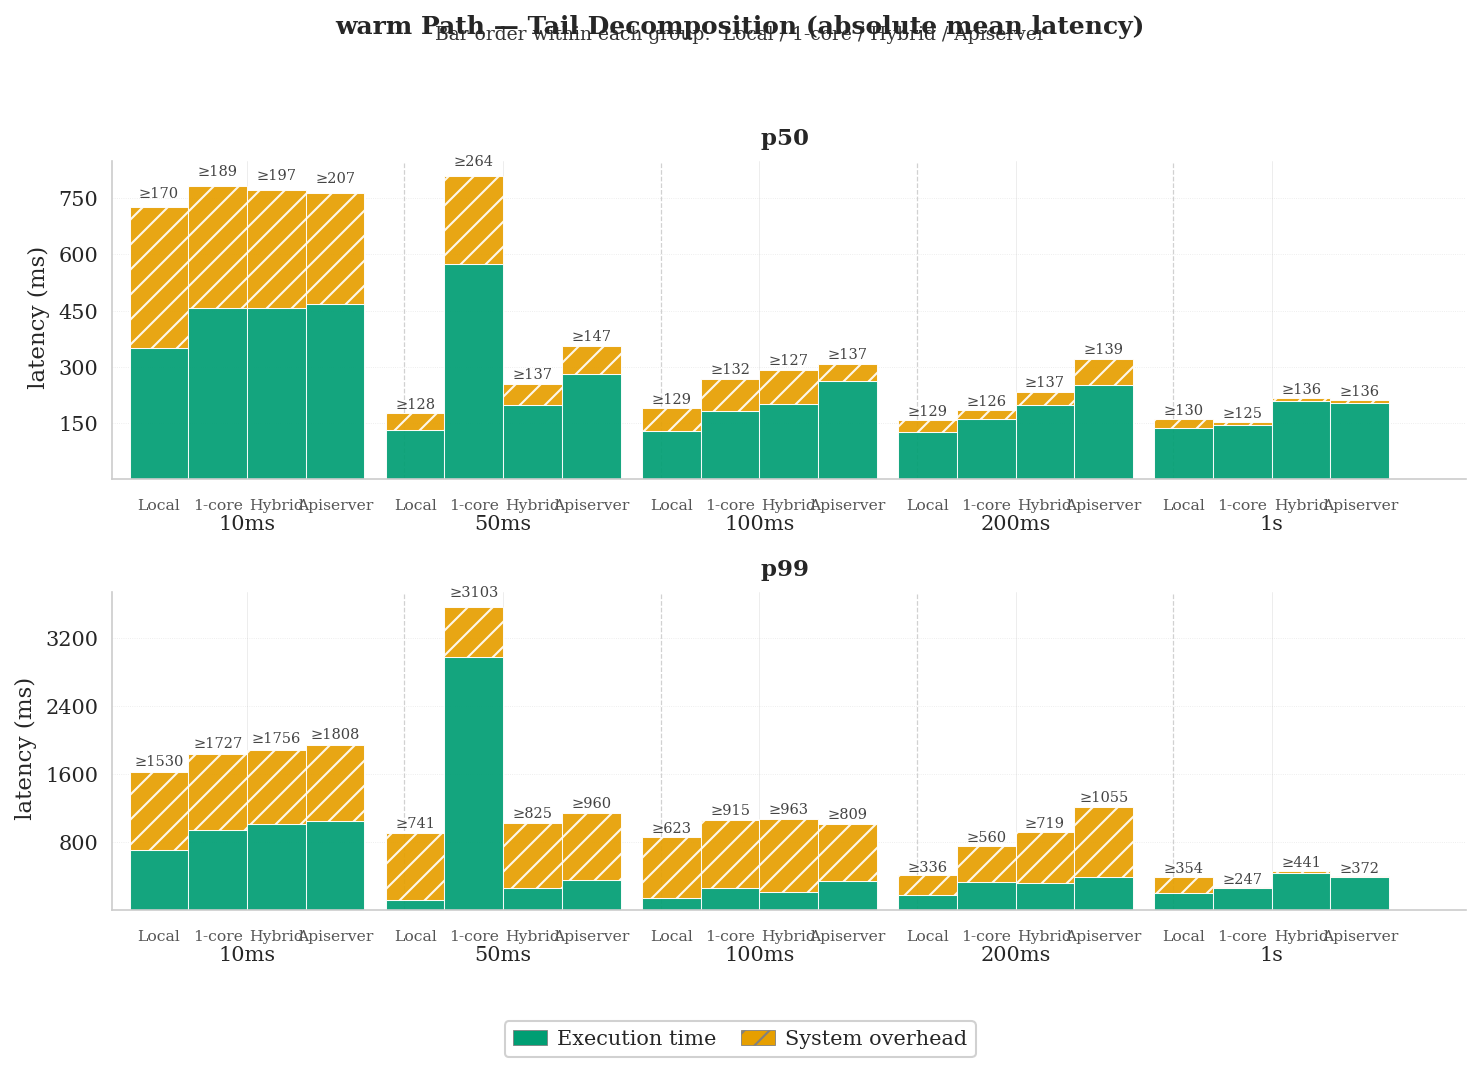

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── Typography & style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "pdf.fonttype":       42,   # embeds fonts properly for ACM/IEEE
    "ps.fonttype":        42,
    "figure.dpi":         150,
})

# ── Data configuration ────────────────────────────────────────────────────────
DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s"]
ARCHS    = ["Hybrid", "Local", "Local 1core","Local Apiserver"]
DATA_DIR = "."
FILES = {
    "Local":       {d: f"all_data_decomposed_{d}.csv"         for d in DELAYS},
    "Local 1core": {d: f"all_data_decomposed_{d}_1core.csv"   for d in DELAYS},
    "Hybrid":      {d: f"all_data_decomposed_{d}_hybrid.csv"  for d in DELAYS},
   "Local Apiserver": {d: f"all_data_decomposed_{d}_apiserver.csv"  for d in DELAYS}
}

# Stack: only the two decomposed columns (output transfer is implicit remainder)
STACK_COLS    = ["execution_time_ms", "system_overhead_ms"]
STACK_LABELS  = ["Execution time", "System overhead"]
# Colorblind-safe, print-friendly palette (Wong 2011)
STACK_COLORS  = ["#009E73", "#E69F00"]
STACK_HATCHES = ["", "//"]

REQ_TYPE = "warm"

# ── Helpers ───────────────────────────────────────────────────────────────────
def load(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df = df[(df["status"] == 200) & (df["type"] == REQ_TYPE)].copy()
    for col in STACK_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df if len(df) > 0 else None


def tail_decomp(df, pctile):
    thresh = np.percentile(df["latency_ms"].dropna(), pctile)
    tail   = df[df["latency_ms"] >= thresh]
    result = {col: (tail[col].mean() if len(tail) > 0 else 0) for col in STACK_COLS}
    result["n_tail"] = len(tail)
    result["thresh"] = thresh
    return result


available = [d for d in DELAYS if any(load(a, d) is not None for a in ARCHS)]
print(f"Delays ({REQ_TYPE}): {available}")

# ── Layout ────────────────────────────────────────────────────────────────────
# One row per percentile; columns = network delays
# Column width generous so group labels breathe
PCTILES    = [50, 99]
ROW_TITLES = ["p50 ",
              "p99 "]
N_ARCH = len(ARCHS)
n      = len(available)

ARCH_LABELS = ["Local", "1-core", "Hybrid","Apiserver"]  # concise x-tick labels

# Group layout: for each delay, 3 bars (one per arch) + small gap between groups
bar_w    = 0.22
gap      = 0.08                              # gap between groups
group_w  = N_ARCH * bar_w + gap
x_groups = np.arange(n) * group_w           # left edge of each group
x_arches = [x_groups + i * bar_w for i in range(N_ARCH)]

fig, axes = plt.subplots(
    len(PCTILES), 1,
    figsize=(max(6, 2.0 * n), 6.5),
    sharex=False,
)
if len(PCTILES) == 1:
    axes = [axes]

for row, (pctile, row_title) in enumerate(zip(PCTILES, ROW_TITLES)):
    ax = axes[row]
    thresh_texts = []

    for ai, arch in enumerate(ARCHS):
        for ci, delay in enumerate(available):
            df = load(arch, delay)
            if df is None:
                thresh_texts.append(None)
                continue

            decomp = tail_decomp(df, pctile)
            bottom = 0
            xpos   = x_arches[ai][ci]

            for col, color, hatch in zip(STACK_COLS, STACK_COLORS, STACK_HATCHES):
                val = decomp.get(col, 0)
                ax.bar(
                    xpos, val,
                    bottom=bottom,
                    width=bar_w,
                    color=color,
                    hatch=hatch,
                    edgecolor="white",
                    linewidth=0.5,
                    alpha=0.92,
                    label=None,
                )
                bottom += val

            # Threshold annotation above bar
            ax.text(
                xpos, bottom + max(bottom * 0.025, 2),
                f"≥{decomp['thresh']:.0f}",
                ha="center", va="bottom",
                fontsize=7, color="#444444",
                rotation=0,
            )

    # ── X-axis: group ticks = delays, minor visual separators ───────────────
    group_centers = x_groups + (N_ARCH * bar_w) / 2 - bar_w / 2
    ax.set_xticks(group_centers)
    ax.set_xticklabels(available, fontsize=10)
    ax.set_xlabel("", fontsize=11, labelpad=6)

    # Arch labels below each bar — secondary level
    for ai, label in enumerate(ARCH_LABELS):
        for ci in range(n):
            ax.text(
                x_arches[ai][ci], -ax.get_ylim()[1] * 0.06,
                label,
                ha="center", va="top",
                fontsize=7.5, color="#555555",
                transform=ax.get_xaxis_transform() if False else ax.transData,
                clip_on=False,
            )

    # Subtle vertical separators between delay groups
    for ci in range(n - 1):
        sep_x = x_groups[ci] + N_ARCH * bar_w + gap / 2
        ax.axvline(sep_x, color="0.82", linewidth=0.6, linestyle="--", zorder=0)

    ax.set_ylabel(" latency (ms)", fontsize=11)
    ax.set_title(row_title, fontsize=11, fontweight="bold", pad=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune="both"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.78", zorder=0)
    ax.tick_params(axis="x", direction="out", length=3, width=0.6, pad=14)
    ax.tick_params(axis="y", direction="out", length=3, width=0.6)

    # Widen x limits slightly for breathing room
    ax.set_xlim(x_groups[0] - bar_w * 0.8, x_groups[-1] + N_ARCH * bar_w + bar_w * 0.8)

# ── Shared legend ─────────────────────────────────────────────────────────────
stack_handles = [
    Patch(facecolor=STACK_COLORS[i], hatch=STACK_HATCHES[i],
          label=STACK_LABELS[i], edgecolor="grey", linewidth=0.4)
    for i in range(len(STACK_COLS))
]
arch_handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=f"C{i}",
           label=ARCH_LABELS[i], markersize=0)
    for i in range(N_ARCH)
]

fig.legend(
    handles=stack_handles,
    loc="lower center",
    ncol=len(STACK_COLS),
    bbox_to_anchor=(0.5, -0.04),
    fontsize=10,
    framealpha=0.9,
    edgecolor="0.8",
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.2,
)

# ── Arch colour legend (top, compact) ─────────────────────────────────────────
arch_patch_handles = [
    Patch(facecolor="none", edgecolor="none",
          label=f"  ← {label}" if i == 0 else label)
    for i, label in enumerate(ARCH_LABELS)
]
# Simple text annotation is cleaner — explain bar order once
fig.text(
    0.5, 1.01,
    f"Bar order within each group:  {' / '.join(ARCH_LABELS)}",
    ha="center", va="bottom", fontsize=9, color="#333333",
    transform=fig.transFigure,
)

fig.suptitle(
    "warm Path — Tail Decomposition (absolute mean latency)",
    fontsize=12, fontweight="bold", y=1.04,
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

out_pdf = "fig_tail_warm_abs.pdf"
out_png = "fig_tail_warm_abs.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"✓ {out_pdf}")
print(f"✓ {out_png}")

Delays: ['10ms', '50ms', '100ms', '200ms', '1s']
✓ Saved tail_decomposition_p99.pdf/png


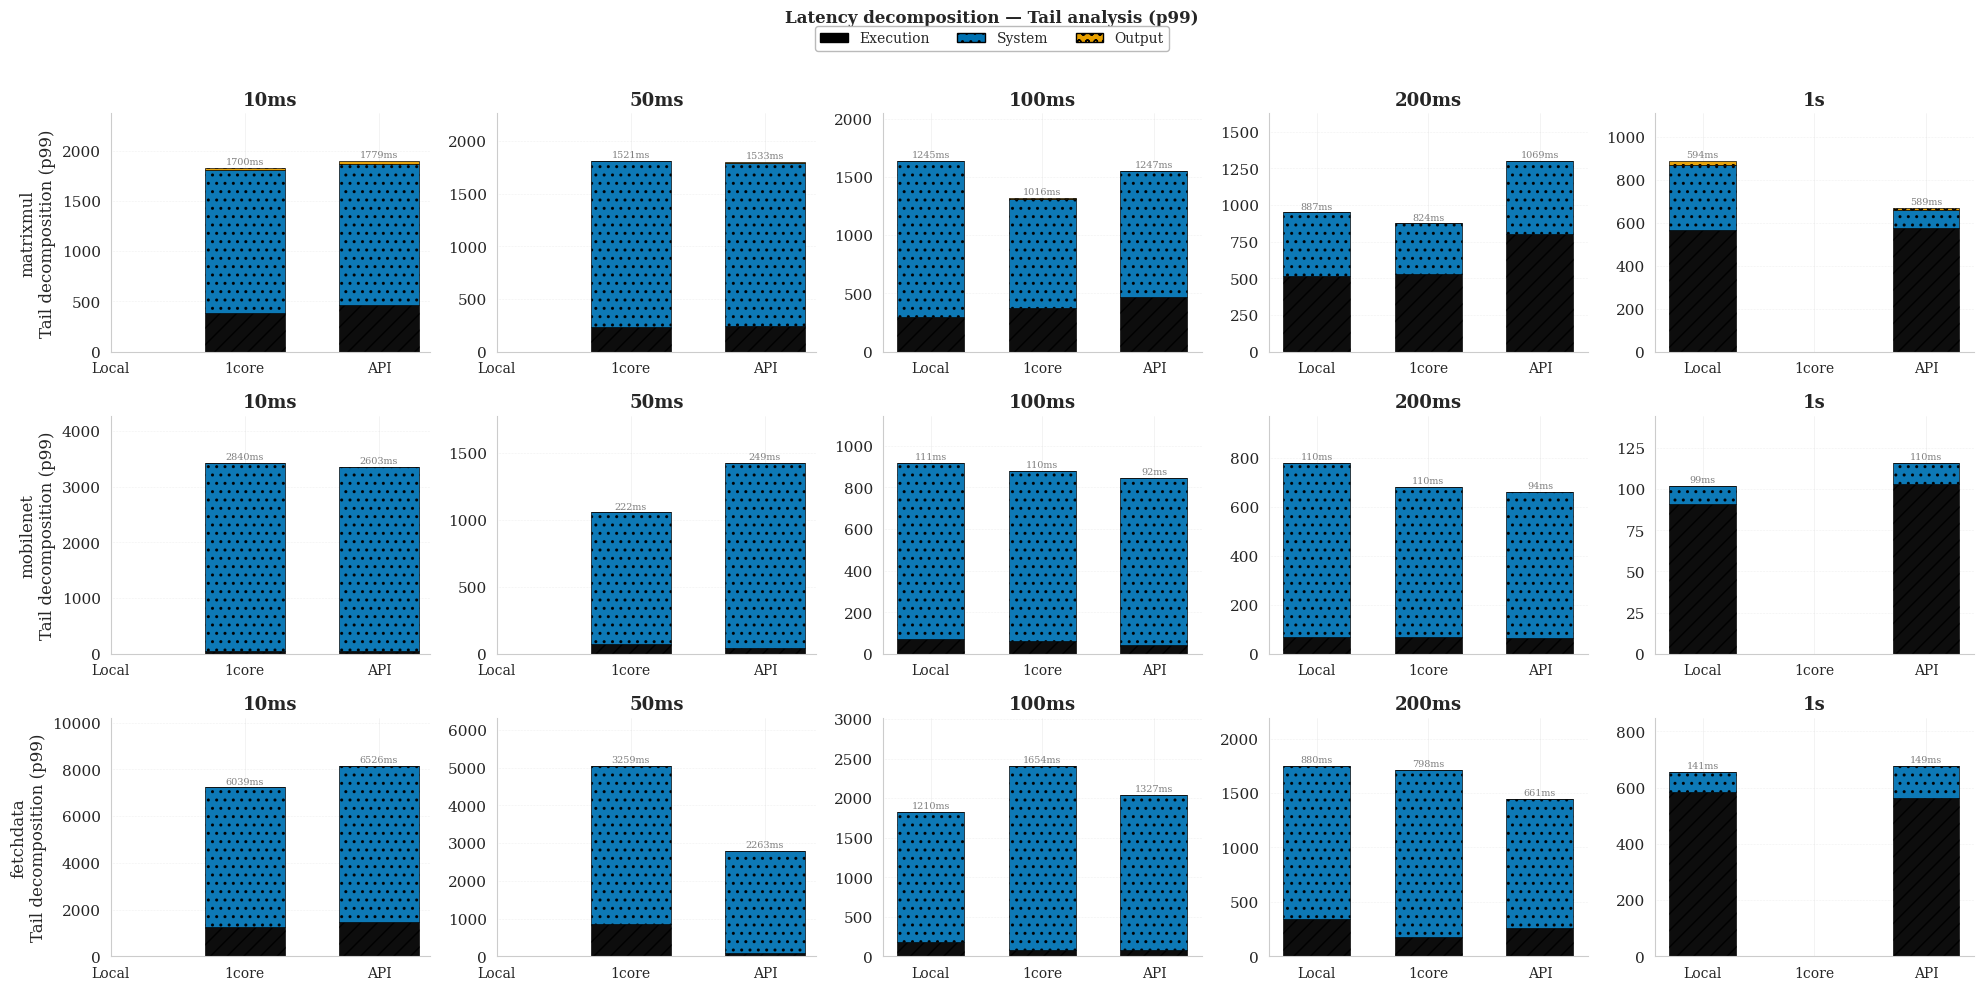

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────
# STYLE OSDI CLEAN
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

ARCHS = ["Local", "Local 1core", "Local APIserver"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: f"all_data_decomposed_{d}.csv" for d in DELAYS
    },
    "Local 1core": {
        d: f"all_data_decomposed_{d}_1core.csv" for d in DELAYS
    },
    "Local APIserver": {
        d: f"all_data_decomposed_{d}_apiserver_pinned.csv" for d in DELAYS
    },
}

FUNCTIONS = [
    "matrixmul",
    "mobilenet",
    "fetchdata"
]

REQ_TYPE = "warm"

STACK_COLS = [
    "execution_time_ms",
    "system_overhead_ms",
    "output_transfer_ms"
]

STACK_LABELS = ["Execution", "System", "Output"]

COLORS = ["#000000", "#0072B2", "#E69F00"]
HATCHES = ["//", "..", "oo"]

# ─────────────────────────────────────────────────────────────
# CHOOSE PERCENTILE HERE
# ─────────────────────────────────────────────────────────────
PERCENTILE_TO_PLOT = 99   # <-- change to 99 for tail

# ─────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────
def load(arch, delay, fn):

    path = FILES[arch][delay]

    if not os.path.exists(path):
        return None

    df = pd.read_csv(path)

    df = df[
        (df["status"] == 200) &
        (df["type"] == REQ_TYPE) &
        (df["function"] == fn)
    ].copy()

    if len(df) == 0:
        return None

    for c in STACK_COLS + ["latency_ms"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.dropna(subset=["latency_ms"])

# ─────────────────────────────────────────────────────────────
# DECOMPOSITION
# ─────────────────────────────────────────────────────────────
def decompose(df, pct):

    thr = np.percentile(df["latency_ms"], pct)
    tail = df[df["latency_ms"] >= thr]

    if len(tail) == 0:
        return None

    return {
        "thr": thr,
        "vals": {c: tail[c].mean() for c in STACK_COLS}
    }

# ─────────────────────────────────────────────────────────────
# AVAILABLE DELAYS
# ─────────────────────────────────────────────────────────────
available = [
    d for d in DELAYS
    if any(load(a, d, FUNCTIONS[0]) is not None for a in ARCHS)
]

print("Delays:", available)

# ─────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(FUNCTIONS),
    len(available),
    figsize=(4 * len(available), 3.2 * len(FUNCTIONS)),
    sharey=False
)

if len(available) == 1:
    axes = axes.reshape(len(FUNCTIONS), 1)

x = np.arange(len(ARCHS))
bar_w = 0.6

for fi, fn in enumerate(FUNCTIONS):

    for di, delay in enumerate(available):

        ax = axes[fi][di]

        global_max = 0

        for ai, arch in enumerate(ARCHS):

            df = load(arch, delay, fn)
            if df is None:
                continue

            d = decompose(df, PERCENTILE_TO_PLOT)
            if d is None:
                continue

            bottom = 0

            for ci, col in enumerate(STACK_COLS):

                val = d["vals"][col]

                ax.bar(
                    ai,
                    val,
                    bottom=bottom,
                    width=bar_w,
                    color=COLORS[ci],
                    hatch=HATCHES[ci],
                    edgecolor="black",
                    linewidth=0.5,
                    alpha=0.95
                )

                bottom += val

            global_max = max(global_max, bottom)

            ax.text(
                ai,
                bottom + global_max * 0.02,
                f"{d['thr']:.0f}ms",
                ha="center",
                fontsize=7,
                color="gray"
            )

        ax.set_title(delay, fontweight="bold")

        if di == 0:
            ax.set_ylabel(
                f"{fn}\nTail decomposition (p{PERCENTILE_TO_PLOT})"
            )

        ax.set_xticks(x)
        ax.set_xticklabels(["Local", "1core", "API"])

        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.75")

        ax.set_ylim(0, global_max * 1.25)

# ─────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────
handles = [
    Patch(facecolor=COLORS[i], hatch=HATCHES[i],
          edgecolor="black", label=STACK_LABELS[i])
    for i in range(3)
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    framealpha=0.9
)

fig.suptitle(
    f"Latency decomposition — Tail analysis (p{PERCENTILE_TO_PLOT})",
    fontsize=12,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

# ─────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────
out = f"tail_decomposition_p{PERCENTILE_TO_PLOT}"

plt.savefig(out + ".pdf", dpi=300, bbox_inches="tight")
plt.savefig(out + ".png", dpi=300, bbox_inches="tight")

print(f"✓ Saved {out}.pdf/png")

✓ Saved client_view_p99.pdf/png


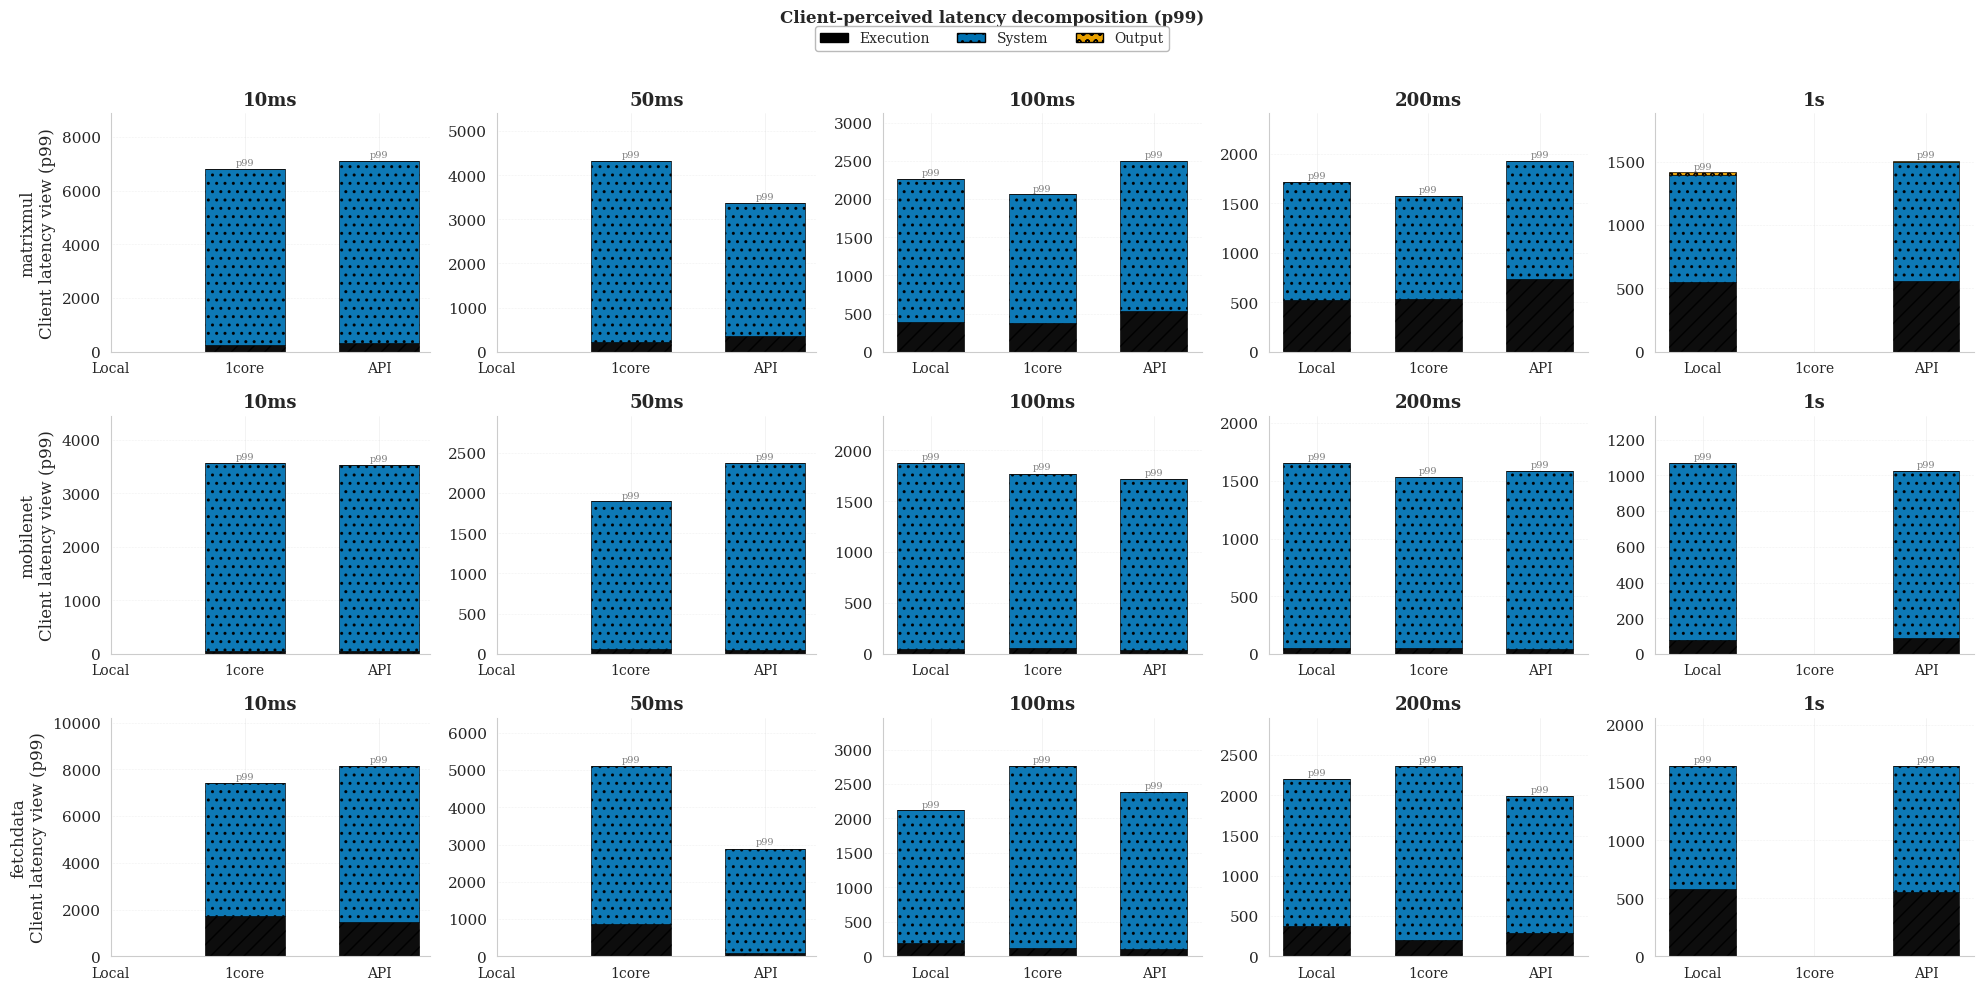

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────
# STYLE OSDI CLEAN
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

ARCHS = ["Local", "Local 1core", "Local APIserver"]

FILES = {
    "Local": {
        d: f"all_data_decomposed_{d}.csv" for d in DELAYS
    },
    "Local 1core": {
        d: f"all_data_decomposed_{d}_1core.csv" for d in DELAYS
    },
    "Local APIserver": {
        d: f"all_data_decomposed_{d}_apiserver_pinned.csv" for d in DELAYS
    },
}

FUNCTIONS = ["matrixmul", "mobilenet", "fetchdata"]

STACK_COLS = [
    "execution_time_ms",
    "system_overhead_ms",
    "output_transfer_ms"
]

STACK_LABELS = ["Execution", "System", "Output"]

COLORS = ["#000000", "#0072B2", "#E69F00"]
HATCHES = ["//", "..", "oo"]

PERCENTILE_TO_PLOT = 99

# ─────────────────────────────────────────────────────────────
# LOAD (NO TYPE FILTER → IMPORTANT)
# ─────────────────────────────────────────────────────────────
def load(arch, delay, fn):

    path = FILES[arch][delay]
    if not os.path.exists(path):
        return None

    df = pd.read_csv(path)

    df = df[
        (df["status"] == 200) &
        (df["function"] == fn)
    ].copy()

    if len(df) == 0:
        return None

    for c in STACK_COLS + ["latency_ms"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.dropna(subset=["latency_ms"])

# ─────────────────────────────────────────────────────────────
# DECOMPOSITION
# ─────────────────────────────────────────────────────────────
def decompose(df, pct):

    thr = np.percentile(df["latency_ms"], pct)
    tail = df[df["latency_ms"] >= thr]

    if len(tail) == 0:
        return None

    return {
        "thr": thr,
        "vals": {c: tail[c].mean() for c in STACK_COLS}
    }

# ─────────────────────────────────────────────────────────────
available = [
    d for d in DELAYS
    if any(load(a, d, FUNCTIONS[0]) is not None for a in ARCHS)
]

fig, axes = plt.subplots(
    len(FUNCTIONS),
    len(available),
    figsize=(4 * len(available), 3.2 * len(FUNCTIONS)),
    sharey=False
)

if len(available) == 1:
    axes = axes.reshape(len(FUNCTIONS), 1)

x = np.arange(len(ARCHS))
bar_w = 0.6

for fi, fn in enumerate(FUNCTIONS):

    for di, delay in enumerate(available):

        ax = axes[fi][di]
        global_max = 0

        for ai, arch in enumerate(ARCHS):

            df = load(arch, delay, fn)
            if df is None:
                continue

            d = decompose(df, PERCENTILE_TO_PLOT)
            if d is None:
                continue

            bottom = 0

            for ci, col in enumerate(STACK_COLS):

                val = d["vals"][col]

                ax.bar(
                    ai,
                    val,
                    bottom=bottom,
                    width=bar_w,
                    color=COLORS[ci],
                    hatch=HATCHES[ci],
                    edgecolor="black",
                    linewidth=0.5,
                    alpha=0.95
                )

                bottom += val

            global_max = max(global_max, bottom)

            ax.text(
                ai,
                bottom + global_max * 0.02,
                f"p{PERCENTILE_TO_PLOT}",
                ha="center",
                fontsize=7,
                color="gray"
            )

        ax.set_title(delay, fontweight="bold")

        if di == 0:
            ax.set_ylabel(f"{fn}\nClient latency view (p{PERCENTILE_TO_PLOT})")

        ax.set_xticks(x)
        ax.set_xticklabels(["Local", "1core", "API"])

        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.75")

        ax.set_ylim(0, global_max * 1.25)

# ─────────────────────────────────────────────────────────────
handles = [
    Patch(facecolor=COLORS[i], hatch=HATCHES[i],
          edgecolor="black", label=STACK_LABELS[i])
    for i in range(3)
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    framealpha=0.9
)

fig.suptitle(
    f"Client-perceived latency decomposition (p{PERCENTILE_TO_PLOT})",
    fontsize=12,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

out = f"client_view_p{PERCENTILE_TO_PLOT}"
plt.savefig(out + ".pdf", dpi=300, bbox_inches="tight")
plt.savefig(out + ".png", dpi=300, bbox_inches="tight")

print(f"✓ Saved {out}.pdf/png")

In [51]:
for arch in ARCHS:
    print("RUNNING ARCH:", arch)

    df = load(arch, delay, fn)

    print("\nDEBUG LOAD", arch, delay, fn)

    if df is None:
        print("❌ DF is None (filtered out completely)")
        continue

    print("before filter:", len(df))

RUNNING ARCH: Local

DEBUG LOAD Local 1s fetchdata
before filter: 2170
RUNNING ARCH: Local 1core

DEBUG LOAD Local 1core 1s fetchdata
❌ DF is None (filtered out completely)
RUNNING ARCH: Local APIserver

DEBUG LOAD Local APIserver 1s fetchdata
before filter: 2170


Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [ABS] Local                               / 10ms p50=5671.9 p99=23311.8
  [ABS] Hybrid                              / 10ms p50=3753.6 p99=22710.5
  [ABS] Local 1core                         / 10ms p50=5617.8 p99=24205.7
  [ABS] Local (API server + pinned)         / 10ms p50=5408.4 p99=23419.6
  [ABS] Local                               / 50ms p50=16.1 p99=5854.6
  [ABS] Hybrid                              / 50ms p50=14.5 p99=4932.5
  [ABS] Local 1core                         / 50ms p50=13.7 p99=5354.3
  [ABS] Local (API server + pinned)         / 50ms p50=15.8 p99=5640.4
  [ABS] Local                               / 100ms p50=12.1 p99=4447.7
  [ABS] Hybrid                              / 100ms p50=13.4 p99=4893.2
  [ABS] Local 1core                         / 100ms p50=12.8 p99=4104.7
  [ABS] Local (API server + pinned)         / 100ms p50=13.1 p99=3828.2
  [ABS] Local                               / 200ms p50=11.9 p99=4143.2
 

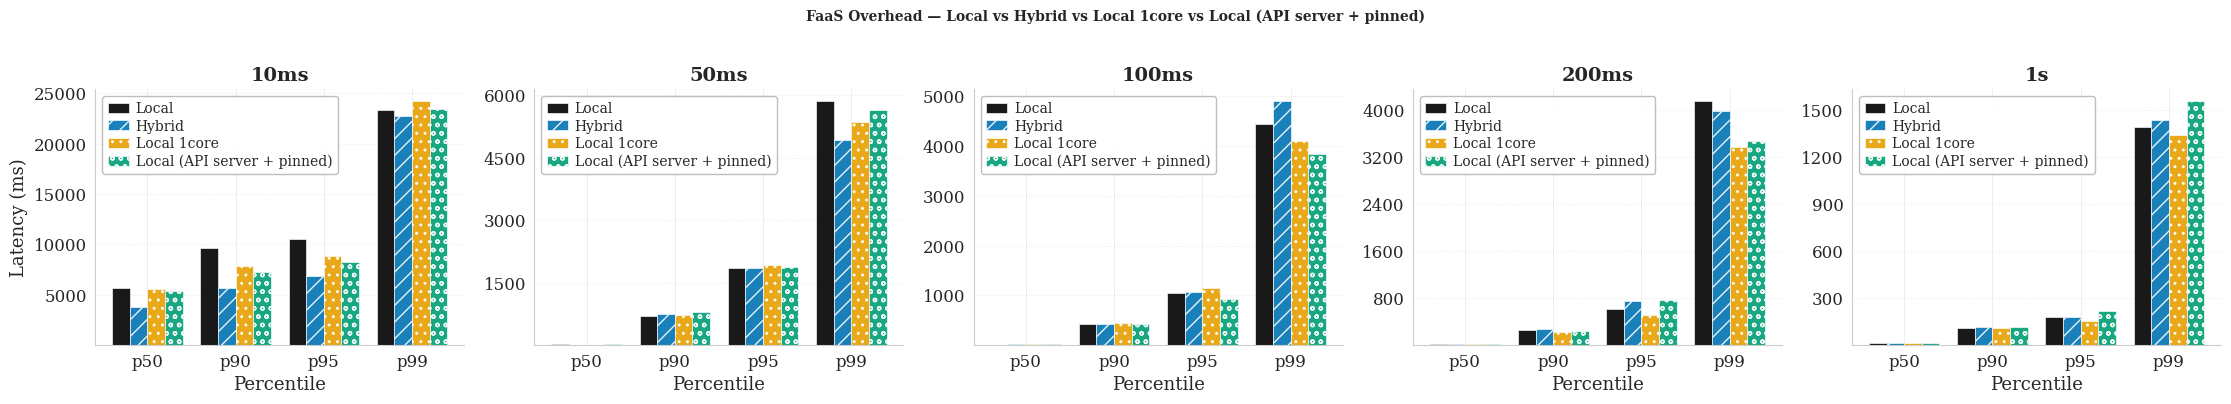

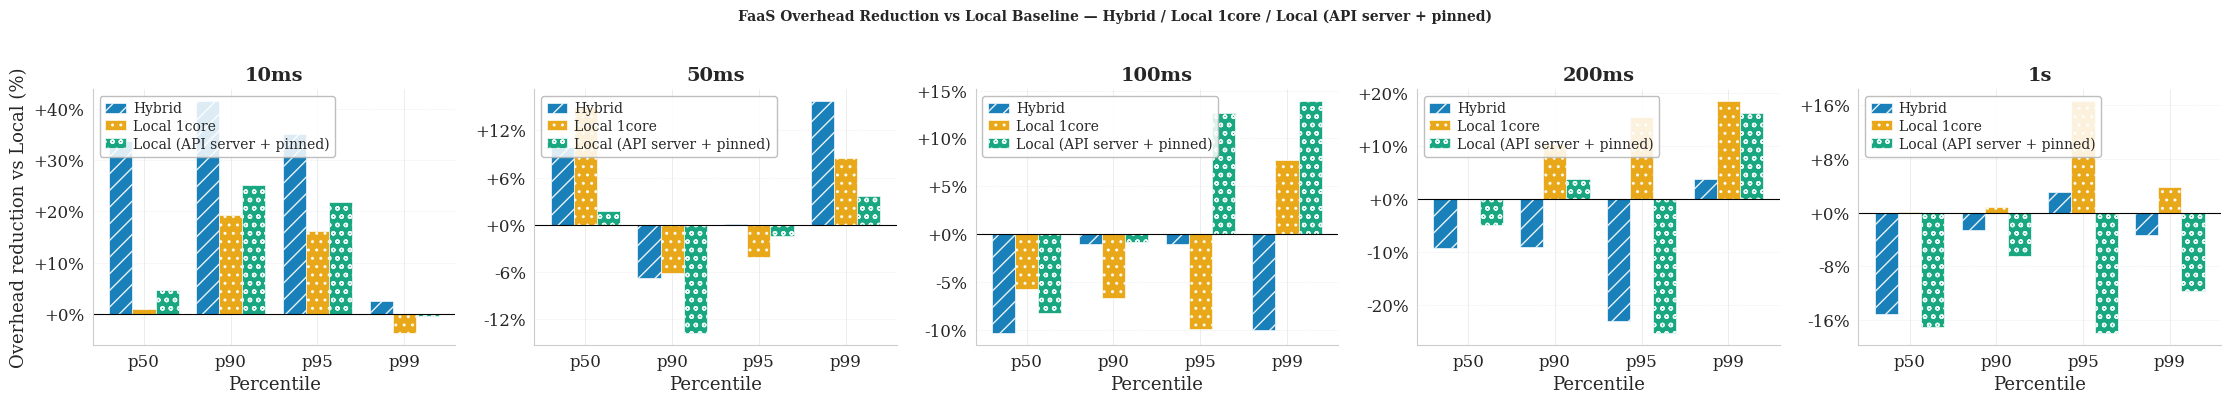

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "0.75",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS  = ["#0072B2", "#E69F00", "#009E73"]
HATCHES = ["//",      "..",      "oo"]
LABELS  = ["Hybrid", "Local 1core", "Local (API server + pinned)"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS        = ["10ms", "50ms", "100ms", "200ms", "1s"]
PERCENTILES   = [50, 90, 95, 99]
PCTILE_LABELS = ["p50", "p90", "p95", "p99"]

DATA_DIR = "."

FILES = {
    "Local":           {d: os.path.join(DATA_DIR, f"all_data_{d}.csv")                  for d in DELAYS},
    "Hybrid":          {d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv")           for d in DELAYS},
    "Local1core":      {d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv")            for d in DELAYS},
    "APIserverPinned": {d: os.path.join(DATA_DIR, f"all_data_{d}_apiserver_pinned.csv") for d in DELAYS},
}

COMPARE_MODES = ["Hybrid", "Local1core", "APIserverPinned"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if not filepath or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    if "diff" not in df.columns:
        return None
    return df["diff"].dropna()

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    local_ok = os.path.exists(FILES["Local"][d])
    has_any  = any(os.path.exists(FILES[m][d]) for m in COMPARE_MODES)
    if local_ok and has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé.")

# ─── FIGURE 1 : overhead absolu (ms) ──────────────────────────────────
n         = len(available_delays)
n_modes   = len(COMPARE_MODES) + 1   # Local + 3
n_pctiles = len(PERCENTILES)
x         = np.arange(n_pctiles)
bar_width = 0.8 / n_modes

fig1, axes1 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes1 = [axes1]

all_modes  = ["Local"] + COMPARE_MODES
all_colors = ["#000000"] + COLORS
all_hatch  = [""] + HATCHES
all_labels = ["Local"] + LABELS

for c, delay in enumerate(available_delays):
    ax = axes1[c]
    for i, mode in enumerate(all_modes):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = [np.percentile(data, p) for p in PERCENTILES]
        offset = (i - n_modes / 2 + 0.5) * bar_width
        ax.bar(x + offset, vals, width=bar_width,
               color=all_colors[i], hatch=all_hatch[i],
               label=all_labels[i], edgecolor="white",
               linewidth=0.5, alpha=0.9)
        print(f"  [ABS] {all_labels[i]:35s} / {delay} p50={vals[0]:.1f} p99={vals[3]:.1f}")

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Latency (ms)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig1.suptitle("FaaS Overhead — Local vs Hybrid vs Local 1core vs Local (API server + pinned)",
              fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig1.savefig("overhead_abs.pdf", dpi=300, bbox_inches="tight")
fig1.savefig("overhead_abs.png", dpi=300, bbox_inches="tight")
print("\n✓ Saved: overhead_abs.pdf / .png")

# ─── FIGURE 2 : gain relatif vs Local (%) ─────────────────────────────
# Message OSDI : "combien de % de gain par rapport à Local ?"
# Valeur positive = amélioration, négative = dégradation

fig2, axes2 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes2 = [axes2]

for c, delay in enumerate(available_delays):
    ax = axes2[c]

    base_data = load_series(FILES["Local"][delay])
    if base_data is None:
        continue
    base_vals = np.array([np.percentile(base_data, p) for p in PERCENTILES])

    n_cmp     = len(COMPARE_MODES)
    bar_width2 = 0.8 / n_cmp

    for i, mode in enumerate(COMPARE_MODES):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = np.array([np.percentile(data, p) for p in PERCENTILES])
        # gain % : positif = moins d'overhead que Local
        gains  = (base_vals - vals) / base_vals * 100
        offset = (i - n_cmp / 2 + 0.5) * bar_width2

        bars = ax.bar(x + offset, gains, width=bar_width2,
                      color=COLORS[i], hatch=HATCHES[i],
                      label=LABELS[i], edgecolor="white",
                      linewidth=0.5, alpha=0.9)

        print(f"  [REL] {LABELS[i]:35s} / {delay} "
              f"p50={gains[0]:+.1f}%  p99={gains[3]:+.1f}%")

    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Overhead reduction vs Local (%)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig2.suptitle(
    "FaaS Overhead Reduction vs Local Baseline — Hybrid / Local 1core / Local (API server + pinned)",
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig2.savefig("overhead_relative.pdf", dpi=300, bbox_inches="tight")
fig2.savefig("overhead_relative.png", dpi=300, bbox_inches="tight")
print("✓ Saved: overhead_relative.pdf / .png")

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 19992 samples, median=57.1ms, p99=3166.3ms
  [OK]   Hybrid / 10ms — 19984 samples, median=51.7ms, p99=3082.6ms
  [OK]   Local 1core / 10ms — 19991 samples, median=53.5ms, p99=3059.9ms
  [OK]   Local / 50ms — 20008 samples, median=23.2ms, p99=2723.0ms
  [OK]   Hybrid / 50ms — 20009 samples, median=23.2ms, p99=2708.8ms
  [OK]   Local 1core / 50ms — 20008 samples, median=23.4ms, p99=2740.3ms
  [OK]   Local / 100ms — 20008 samples, median=22.9ms, p99=2700.6ms
  [OK]   Hybrid / 100ms — 20009 samples, median=23.3ms, p99=2709.6ms
  [OK]   Local 1core / 100ms — 20009 samples, median=23.1ms, p99=2703.4ms
  [OK]   Local / 200ms — 20010 samples, median=23.3ms, p99=2697.4ms
  [OK]   Hybrid / 200ms — 20010 samples, median=23.4ms, p99=2707.5ms
  [OK]   Local 1core / 200ms — 20010 samples, median=23.2ms, p99=2700.0ms
  [OK]   Local / 1s — 20000 samples, median=23.5ms, p99=2711.9ms
  [OK]   Hybrid / 1s — 20000 samples, 

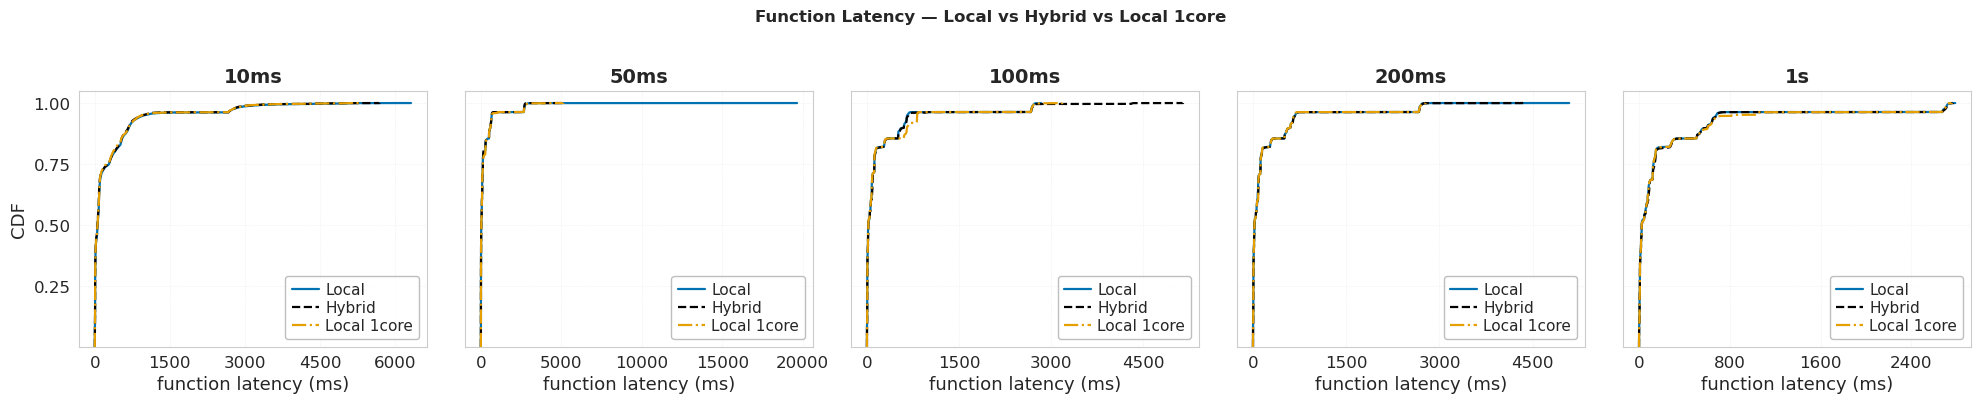

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#0072B2", "#000000",  "#E69F00"]   # noir, bleu, orange
LINESTYLES = ["-",       "--",      "-."]
LABELS     = ["Local", "Hybrid", "Local 1core"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"all_data_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv") for d in DELAYS
    },
}

MODES = ["Local", "Hybrid", "Local 1core"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["execution_time_sec"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("function latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Function Latency — Local vs Hybrid vs Local 1core",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "func_ecdf_overlay.pdf"
out_png = "func_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")